# 🌾 Rice Grain Classification — KNN

**🇹🇷 Türkçe:**
Bu notebook, pirinç tanelerinin geometrik özelliklerinden (alan, eksen uzunlukları, dışbükeylik, çevre, yuvarlaklık, en-boy oranı vb.) tanenin türünü (`Class`: 0 veya 1, iki çeşit arasında) tahmin eden bir K-En Yakın Komşu (KNN) sınıflandırıcısı kuruyor.

Ölçekli bir `Pipeline` + `ColumnTransformer` üzerinde `GridSearchCV` ile `n_neighbors` ve `weights` parametreleri taranıyor.

**🇬🇧 English:**
This notebook builds a K-Nearest Neighbors (KNN) classifier that predicts a rice grain's variety (`Class`: 0 or 1, between two varieties) from its geometric properties (area, axis lengths, eccentricity, perimeter, roundness, aspect ratio, and so on).

`GridSearchCV` tunes `n_neighbors` and `weights` over a scaled `Pipeline` + `ColumnTransformer` setup.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme, görselleştirme ve modelleme için gerekli kütüphaneler tek hücrede toplanıyor.

**🇬🇧 English:**
The libraries needed for data handling, visualization, and modeling are collected in a single cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.dtypes.astype import astype_array

## 📥 1. Veri Setini Yükleme ve İlk Bakış / Load the Dataset and First Look

**🇹🇷 Türkçe:**
Rice Classification veri seti yükleniyor: 18.185 satır, 10 geometrik özellik, bir `id` kolonu ve hedef değişken `Class`. `info()`, `describe()`, eksik değer ve kopya kontrolleri veri setinin temiz olduğunu doğruluyor.

**🇬🇧 English:**
The Rice Classification dataset is loaded: 18,185 rows, 10 geometric features, an `id` column, and the target `Class`. `info()`, `describe()`, and checks for missing values and duplicates confirm the dataset is clean.

In [3]:
df = pd.read_csv("../../Data/20-rice_classification.csv")

In [4]:
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB


In [6]:
df.describe()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,9093.000000,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,5249.701658,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,1.000000,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,4547.000000,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,9093.000000,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,13639.000000,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,18185.000000,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [7]:
df.isnull().sum()

id                 0
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 🧹 2. `id` Kolonunu Kaldırma / Dropping the `id` Column

**🇹🇷 Türkçe:**
`id` yalnızca satır numarasıdır ve tanenin geometrisiyle hiçbir ilişkisi yoktur; modele bırakılırsa gürültü olarak öğrenilebilir. Bu yüzden veri setinden çıkarılıyor.

**🇬🇧 English:**
`id` is just a row number with no relationship to the grain's geometry; leaving it in risks the model learning it as noise. It is therefore dropped from the dataset.

In [11]:
df = df.drop("id", axis=1)

## 🔗 3. Korelasyon ve Çift Değişkenli Görselleştirme / Correlation and Pairwise Visualization

**🇹🇷 Türkçe:**
Korelasyon ısı haritası özellikler arasındaki ilişkileri, `pairplot` ise her özellik çiftinin `Class` etiketine göre nasıl ayrıştığını gösteriyor. Bu, KNN gibi mesafe tabanlı bir modelin sınıfları ne kadar kolay ayırabileceğine dair sezgisel bir ön izleme sunuyor.

**🇬🇧 English:**
The correlation heatmap shows relationships between features, while the `pairplot` shows how each pair of features separates by the `Class` label. This gives an intuitive preview of how easily a distance-based model like KNN should be able to separate the classes.

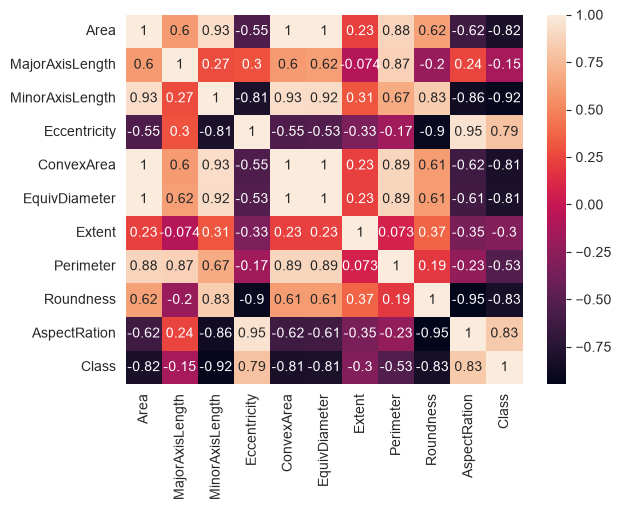

In [15]:
sns.heatmap(df.corr(), annot=True)
plt.show()

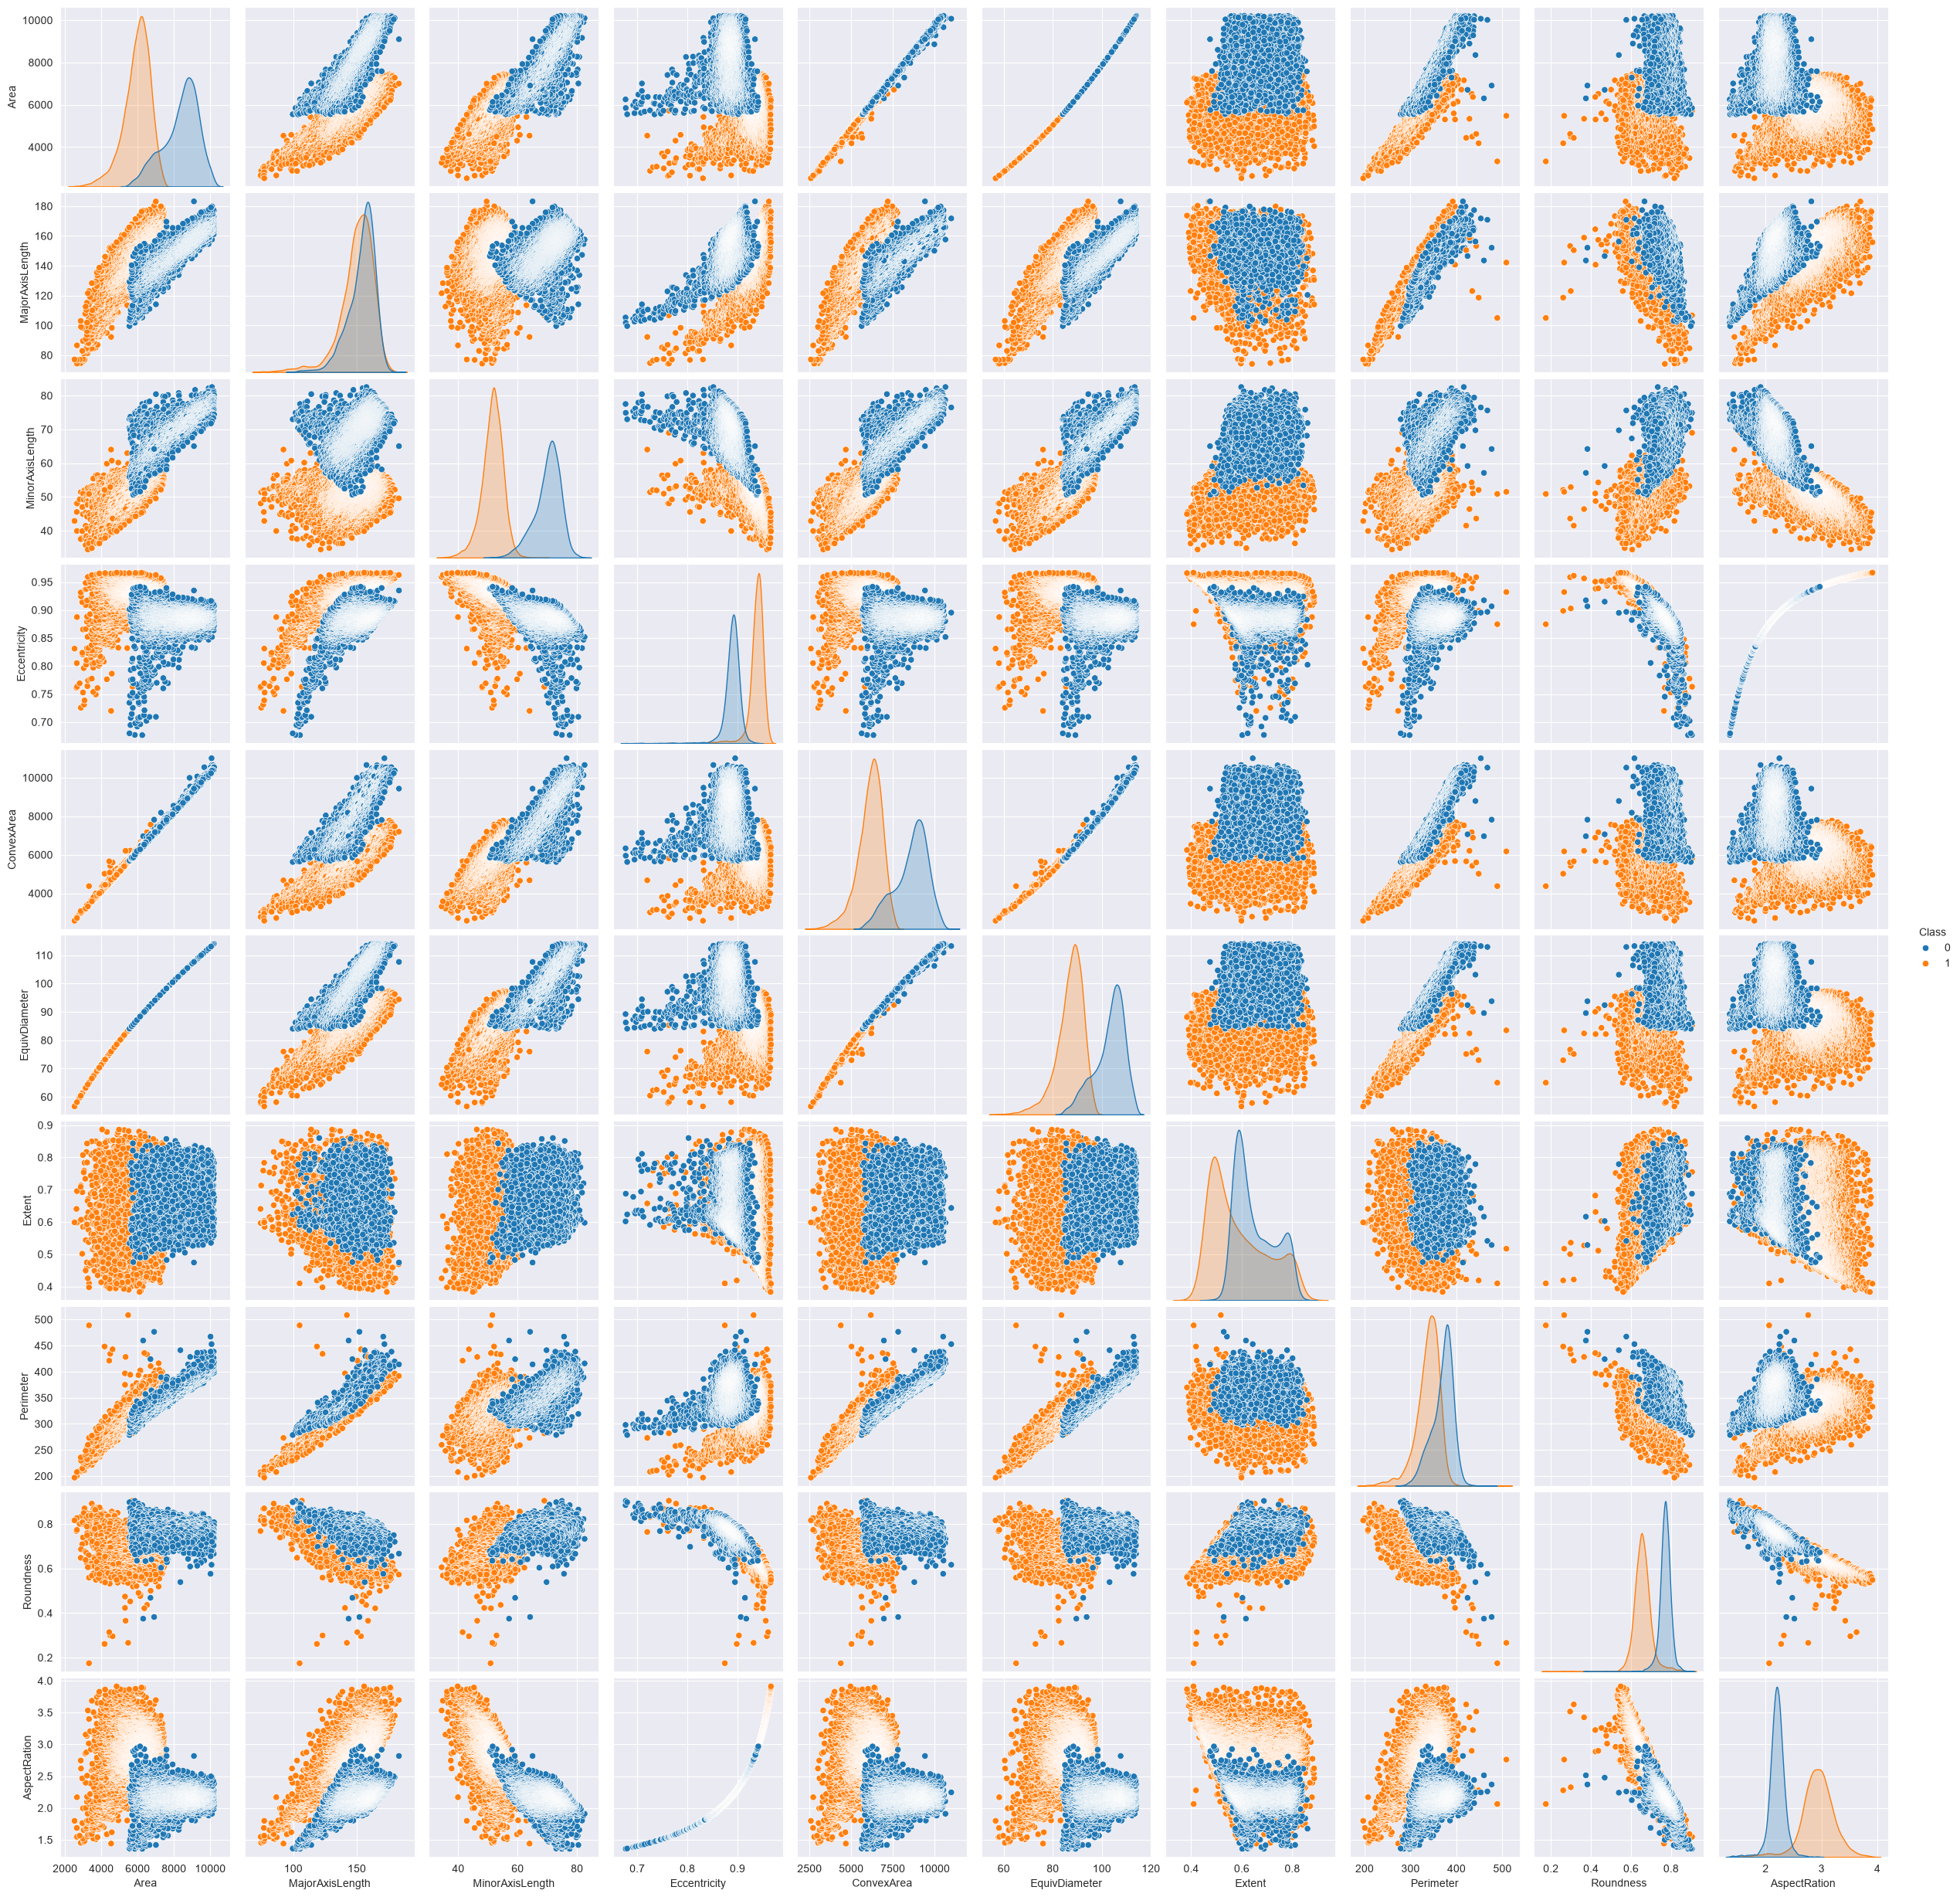

In [18]:
sns.pairplot(df, hue="Class")
plt.show()

## ✂️ 4. Özellik/Hedef Ayrımı ve Train-Test Bölme / Feature-Target Split and Train-Test Split

**🇹🇷 Türkçe:**
Modelleme için gerekli kütüphaneler içe aktarılıyor, `X` (özellikler) ve `y` (hedef `Class`) ayrılıyor. `stratify=y` ile bölme yapılarak her iki sınıfın oranı hem eğitim hem test setinde korunuyor.

**🇬🇧 English:**
The libraries needed for modeling are imported, and `X` (features) and `y` (the target `Class`) are separated. The split uses `stratify=y` so both classes keep the same proportion in the training and test sets.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=15, stratify=y
)

In [34]:
num_cols = X.columns.tolist()

## 📊 5. Dağılım ve Aykırı Değer Kontrolü / Distribution and Outlier Check

**🇹🇷 Türkçe:**
Histogramlar her özelliğin dağılım şeklini, logaritmik ölçekli kutu grafiği ise aykırı değerleri ve özellikler arasındaki ölçek farkını gösteriyor. KNN mesafe tabanlı olduğu için bu ölçek farkı, aşağıdaki `StandardScaler` adımının neden gerekli olduğunu doğruluyor.

**🇬🇧 English:**
Histograms show each feature's distribution shape, while the log-scaled boxplot highlights outliers and the scale differences between features. Since KNN is distance-based, this scale gap confirms why the `StandardScaler` step below is necessary.

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'MajorAxisLength'}>,
        <Axes: title={'center': 'MinorAxisLength'}>],
       [<Axes: title={'center': 'Eccentricity'}>,
        <Axes: title={'center': 'ConvexArea'}>,
        <Axes: title={'center': 'EquivDiameter'}>],
       [<Axes: title={'center': 'Extent'}>,
        <Axes: title={'center': 'Perimeter'}>,
        <Axes: title={'center': 'Roundness'}>],
       [<Axes: title={'center': 'AspectRation'}>, <Axes: >, <Axes: >]],
      dtype=object)

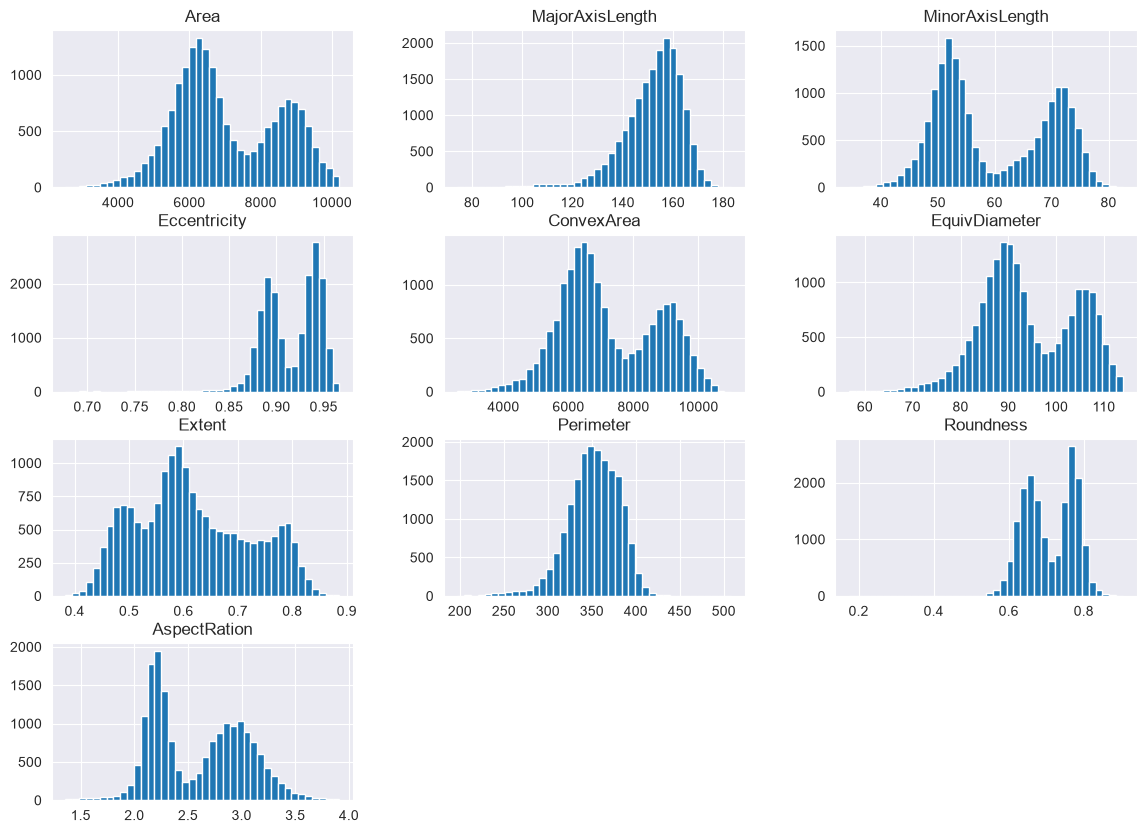

In [35]:
df[num_cols].hist(bins=40, figsize=(14,10))

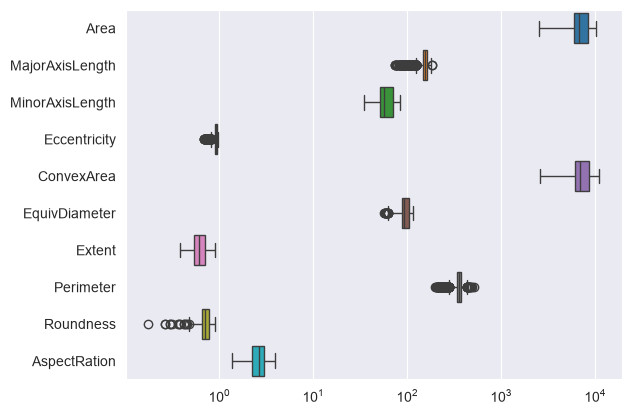

In [41]:
sns.boxplot(data=df[num_cols], orient="h")
plt.xscale("log")

## 🔧 6. Pipeline ve Hiperparametre Optimizasyonu / Pipeline and Hyperparameter Tuning

**🇹🇷 Türkçe:**
`StandardScaler`, `ColumnTransformer` + `Pipeline` içine yerleştirilerek istatistiklerin yalnızca eğitim setinden öğrenilmesi sağlanıyor. `GridSearchCV`, `n_neighbors` (1'den 51'e kadar tek sayılar) ve `weights` (`uniform`/`distance`) parametrelerini tarıyor.

**🇬🇧 English:**
`StandardScaler` is wrapped inside a `ColumnTransformer` + `Pipeline` so its statistics are learned from the training set only. `GridSearchCV` searches over `n_neighbors` (odd numbers from 1 to 51) and `weights` (`uniform`/`distance`).

In [37]:
num_pipeline = Pipeline([("scaler", StandardScaler())])
prep_scaled = ColumnTransformer([("num", num_pipeline, num_cols)])
model_scaled = Pipeline([("prep", prep_scaled), ("knn", KNeighborsClassifier())])

model_scaled

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [38]:
param_grid = {
    "knn__n_neighbors": range(1, 52, 2),
    "knn__weights": ["uniform", "distance"]
}

grid = GridSearchCV(estimator=model_scaled, param_grid=param_grid, scoring="accuracy", n_jobs=-1)


In [39]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': range(1, 52, 2), 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls th

## 📈 7. Sonuçlar / Results

**🇹🇷 Türkçe:**
En iyi parametreler ve karşılık gelen çapraz doğrulama / test skorları yazdırılıyor. Hem CV hem test doğruluğunun **%99** civarında çıkması, iki sınıfın geometrik özelliklerle çok net bir şekilde ayrıştığını gösteriyor — pairplot'ta görülen net ayrım bu sonucu destekliyor.

**🇬🇧 English:**
The best parameters and the corresponding cross-validation/test scores are printed. Both CV and test accuracy landing around **99%** shows the two classes separate very cleanly on these geometric features — consistent with the clear separation seen in the pairplot.

In [40]:
print("En iyi parametreler / Best params:", grid.best_params_)
print("CV skoru / CV score             :", round(grid.best_score_, 3))
print("Test skoru / Test score         :", round(accuracy_score(y_test, grid.predict(X_test)), 3))

En iyi parametreler / Best params: {'knn__n_neighbors': 47, 'knn__weights': 'distance'}
CV skoru / CV score             : 0.99
Test skoru / Test score         : 0.99


## ✅ 8. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- `id` gibi bilgi taşımayan kolonlar modele girmeden çıkarıldı.
- Ölçekli bir `Pipeline` + `ColumnTransformer` üzerinde `GridSearchCV` ile `n_neighbors` ve `weights` parametreleri 5 katlı çapraz doğrulama ile tarandı.
- En iyi model **%99** CV ve test doğruluğuna ulaştı — iki pirinç çeşidinin geometrik özelliklerle neredeyse kusursuz ayrıştığını gösteriyor.
- Ders: Görsel EDA (korelasyon ısı haritası, pairplot) modele geçmeden önce sınıfların ne kadar ayrışabilir olduğuna dair güçlü bir sezgi verebilir.

**🇬🇧 English:**
- Uninformative columns like `id` were dropped before modeling.
- `GridSearchCV` tuned `n_neighbors` and `weights` over a scaled `Pipeline` + `ColumnTransformer`, using 5-fold cross-validation.
- The best model reached **99%** CV and test accuracy — showing the two rice varieties separate almost perfectly on their geometric features.
- Takeaway: visual EDA (correlation heatmap, pairplot) can give a strong intuition for how separable the classes are before any modeling happens.